## Human Activity Recognition for Healthy Lifestyle Monitoring

This project focuses on building a machine learning pipeline to classify five basic human activities: sitting down, standing up, walking, running, and climbing stairs—using smartphone sensor data (accelerometer, gyroscope, gravity).  

**Background and Relevance :**
Human Activity Recognition (HAR) using wearable sensors plays a key role in modern health monitoring, as seen in fitness trackers and smartwatches. Reliable detection of daily activities can support healthy lifestyle interventions, especially for elderly populations. This assignment focuses on five core activities, sitting down, standing up, walking, running, and climbing stairs, to explore how sensor-based data can be transformed into actionable insights for wellness and digital health applications.

**Aim and Research Questions :**
The goal is to develop and evaluate machine learning models that classify these activities using smartphone sensor data to support healthy lifestyle monitoring.

Key questions to address:
1. Which sensor-derived features best distinguish the five target activities?
2. How do supervised vs. unsupervised learning approaches compare for this classification task?
3. Which model achieves the highest accuracy and reliability when combined with appropriate feature extraction and selection?
4. What are the practical considerations and limitations for deploying such systems in real-world health monitoring contexts?


Import Libraries:

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path
import pandas as pd
import importlib
from src.preprocessing import process_folder, detect_trim_bounds_rms_intersection
import  shutil
import matplotlib.pyplot as plt
import numpy as np
import src.preprocessing
importlib.reload(src.preprocessing)  # for debugging

from src.preprocessing import detect_trim_bounds_rms_intersection

# Add the src folder to the Python module search path
sys.path.append(os.path.abspath("src"))
PROJECT_ROOT = Path.cwd().resolve()
RAW_BASE   = PROJECT_ROOT / "data" / "raw"
TRIMMED_BASE = PROJECT_ROOT / "data" / "trimmed_data"

from data_loader import *
from visualization import *
from preprocessing import *

# Load all data into memory
all_data = load_all_data(RAW_BASE, print_option=False)

Data Loaded
Raw Data Classes: ['running', 'sit_down', 'stairs', 'stand_up', 'walking']


### Data Collection Procedure

We used two different methods for collecting activity data:

1. **Continuous recordings**  
   - Applied to activities such as **running, walking, and climbing stairs**.  
   - These activities can be performed continuously without interruption.  
   - As a result, the recordings are relatively long.

     **Recording Procedure:** The smartphone was secured on the subject’s left arm while standing still. The recording began in this position, after which the subject performed the activity, running, walking, or climbing stairs, in a straight line. Once the activity was completed, the subject remained still until the recording was stopped.
     
2. **Single-instance recordings**  
   - Applied to **sitting down** and **standing up** activities.  
   - Each recording contains **only one instance** of the activity.  
   - These recordings are therefore relatively short.

     **Recording Procedure:** For the sitting-down activity, the smartphone was secured on the subject’s left arm while they stood still in front of a chair. Recording began, and after 1–2 seconds the subject performed the sitting-down action. The recording continued for another 1–2 seconds while the subject remained seated, then was stopped. The same procedure was followed for the standing-up activity.

Below are the visualized plots of **raw** accelerometer, gyroscope, and gravity sensor recordings from randomly selected samples of each activity group.

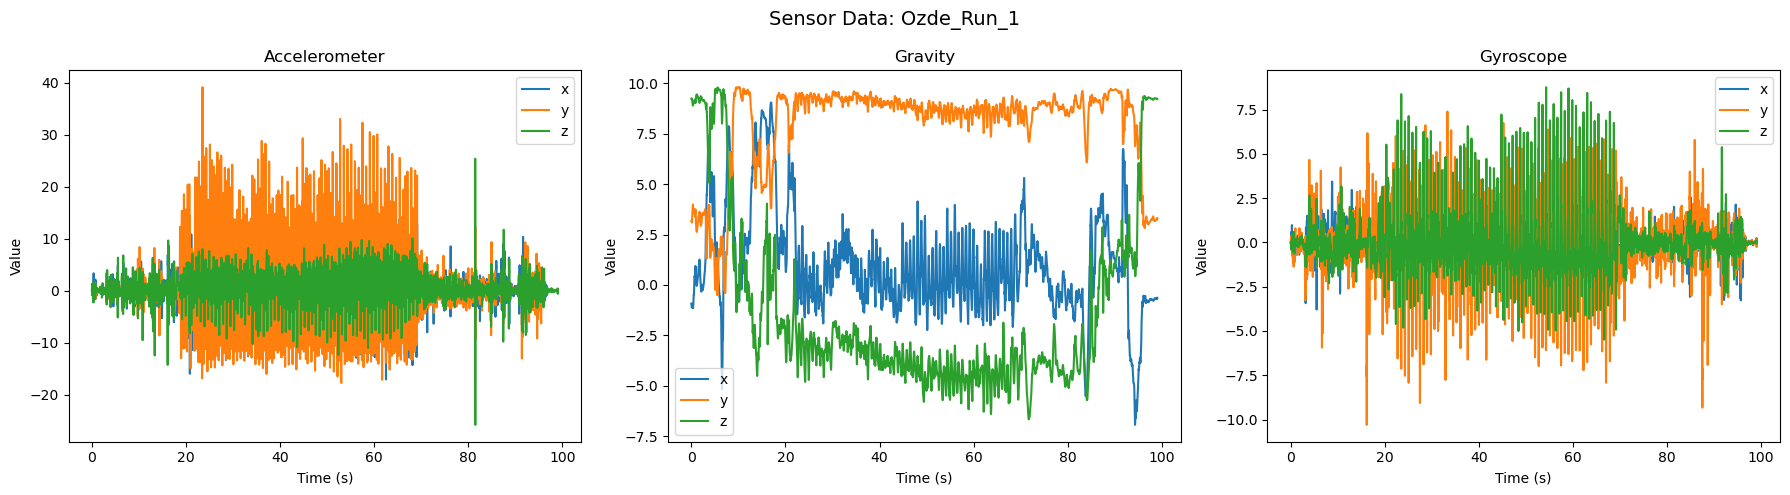

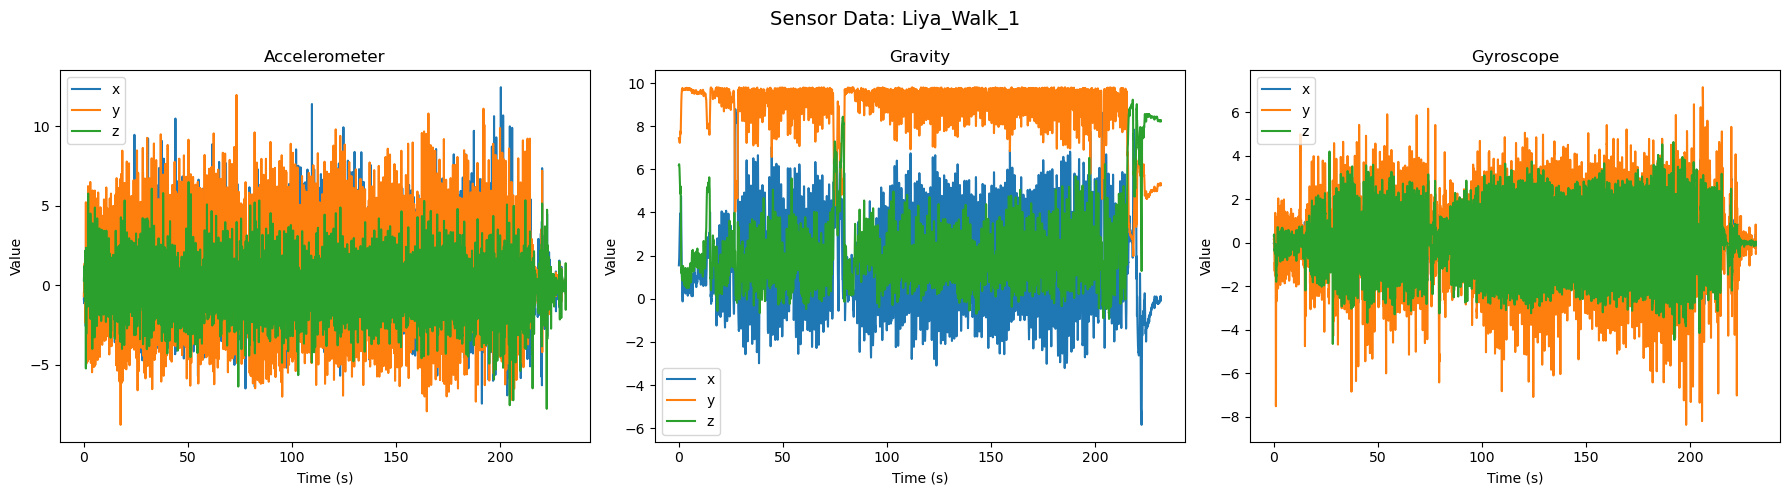

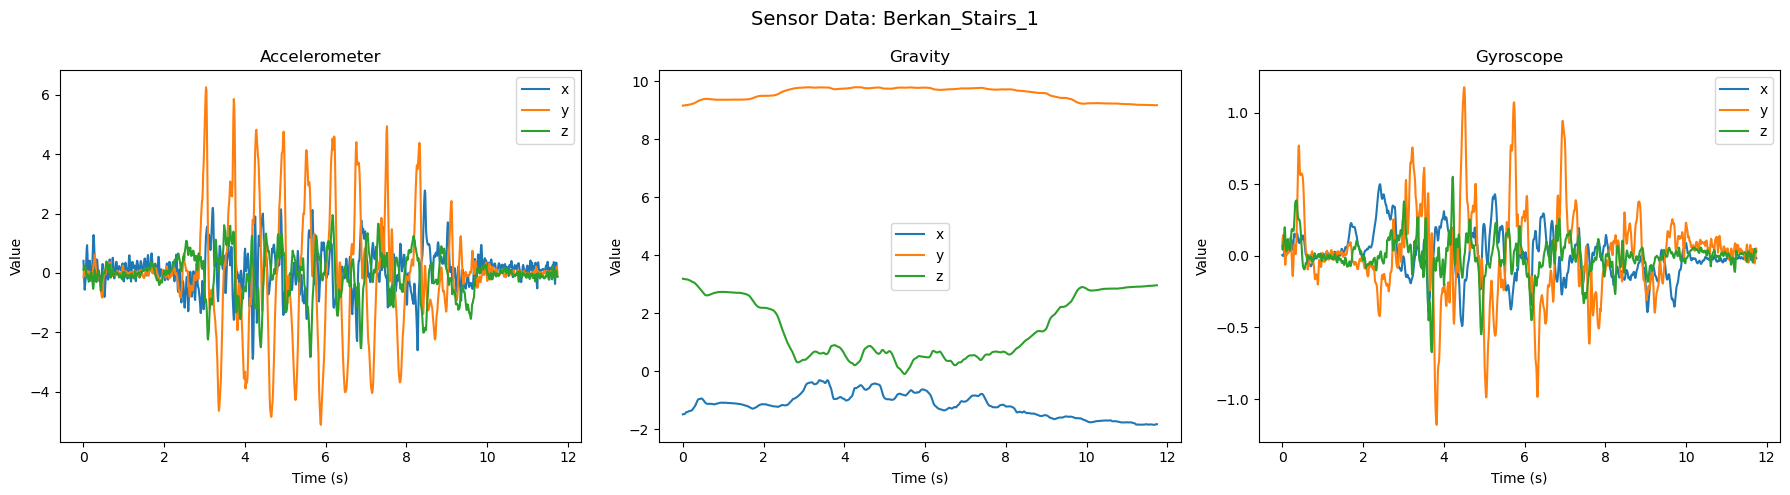

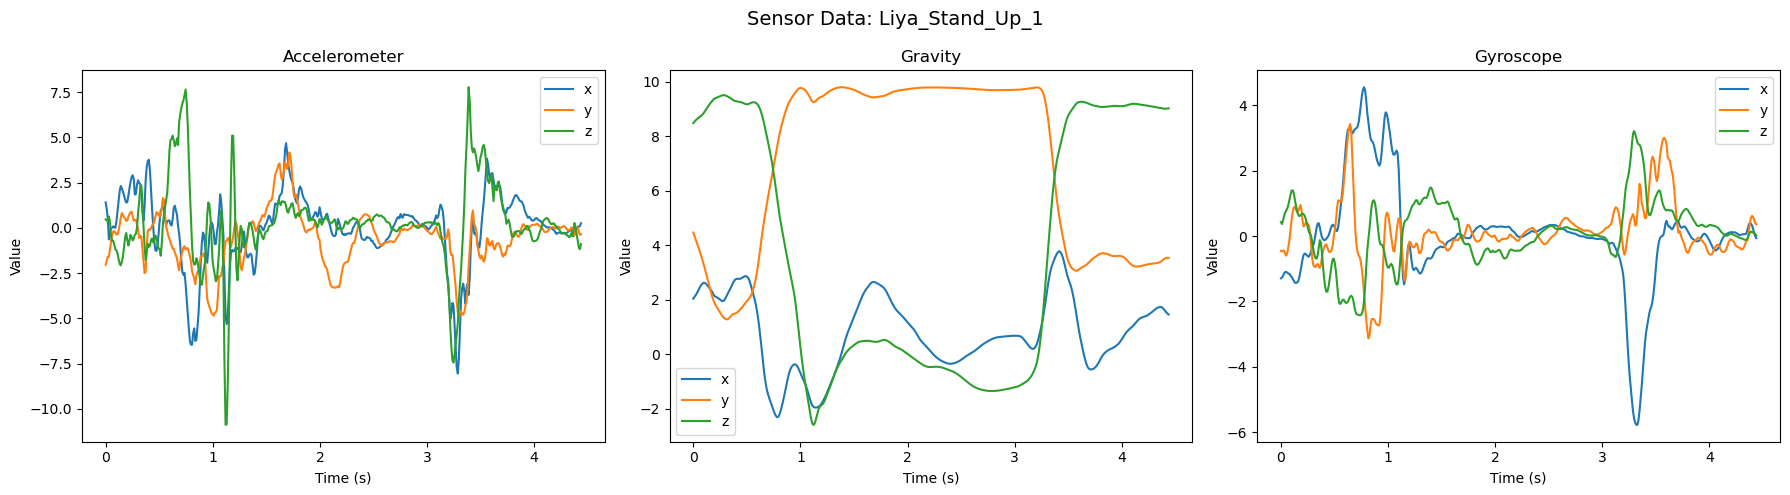

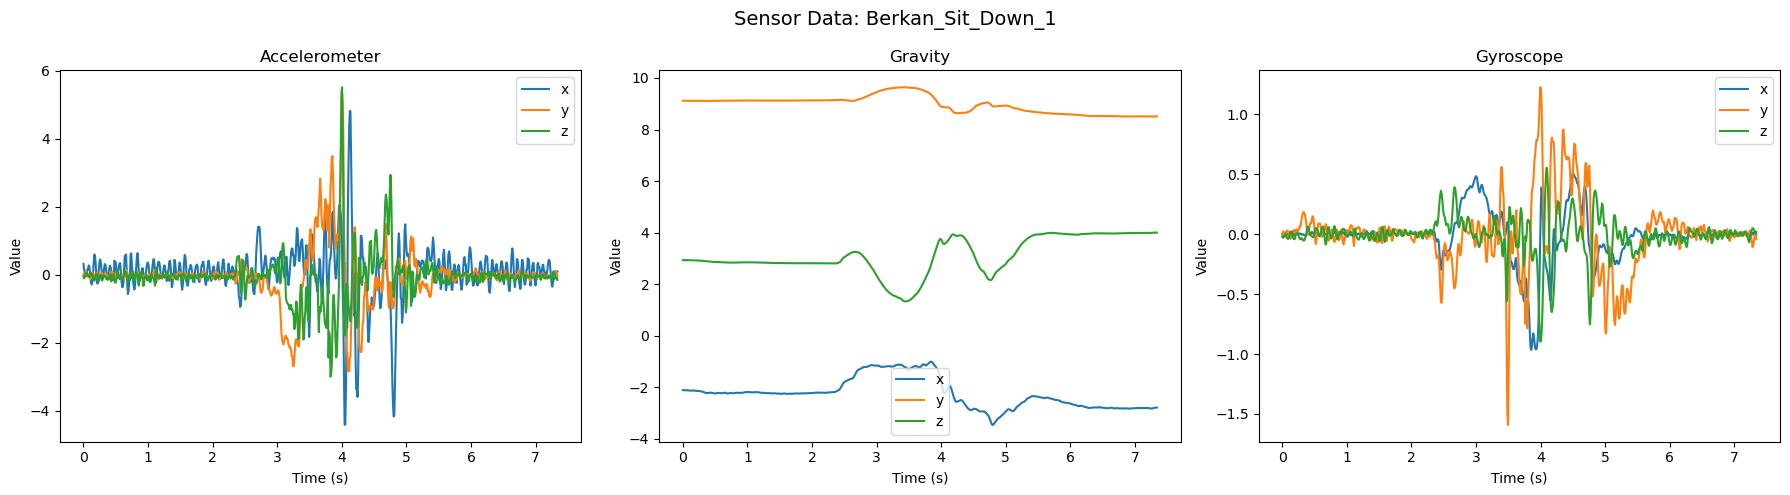

In [3]:
plot_activity(RAW_BASE / "running" / "Ozde_Run_1")
plot_activity(RAW_BASE / "walking" / "Liya_Walk_1")
plot_activity(RAW_BASE / "stairs" / "Berkan_Stairs_1")
plot_activity(RAW_BASE / "stand_up" / "Liya_Stand_Up_1")
plot_activity(RAW_BASE / "sit_down" / "Berkan_Sit_Down_1")

We start processing the raw data by first removing the inactive segments at the beginning and end of each recording, retaining only the portion where the activity is actually performed.
Additionally, we discard any segments recorded while placing the phone into the armband, as these movements do not represent the target activity.

- **For Continuous activities (running / walking / climbing stairs):** Each recording was trimmed to remove non-activity segments and then divided into multiple data samples using 3-second windows with 50% overlap.

In [4]:
WINDOW_SIZE = 3

preprocess_running(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_walking(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False) # show_plots=False to disable plots
preprocess_stairs(TRIMMED_BASE, all_data, window_size=WINDOW_SIZE, show_plots=False)  # show_plots=False to disable plots


 Processing running | Folder: Berkan_Run_1
  Trim 7.50 → 65.90, 38 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Berkan_Run_2
  Trim 7.51 → 67.41, 39 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_1
  Trim 20.96 → 67.26, 29 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_2
  Trim 12.00 → 82.19, 45 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_3
  Trim 19.47 → 80.70, 39 windows, saved in C:\Users\yusuf\Documents\Python_Projects\Data-Analytics-and-Learning-Methods\data\trimmed_data\running

 Processing running | Folder: Ozde_Run_4
  Trim 17.98 → 7

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Running Recordings:

![](figures\running_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

Example plot of the RMS Intersection Based Trim Detection Procedure for Raw Walking Recordings:

![](figures\walking_rms_intersection_based_trim_detection.png)

[Explanation of this plot goes here: How the RMS energy used to find the trimming points etc.]

- **For single-instance activities (sit-down / stand-up):**
Each single-instance activity (sit-down / stand-up) was trimmed to a 3-second window, centered on the activity itself, to remove non-activity segments.

In [5]:
WINDOW_SIZE = 3.0 #Seconds

results = trim_sitdown_standup(RAW_BASE, TRIMMED_BASE, window_size=WINDOW_SIZE)

Done. Processed: 60 | Skipped: 0


[An explanation of the trimming procedure of sitdown and standup activities will added here with a plot]

Now we can collect all windowed activity data into a single CSV file.

[Also Explain which/why features are extracted from x, y and z sensor recordings]

In [6]:
from create_csv import *

OUT_CSV = PROJECT_ROOT / "dataset.csv"

audit_windows(TRIMMED_BASE)
df = build_dataset_from_windows(TRIMMED_BASE, OUT_CSV, keep_ids=True)

[Audit]
  - running: expected=276, usable=276, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - sit_down: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stairs: expected=15, usable=15, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - stand_up: expected=30, usable=30, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}
  - walking: expected=481, usable=481, skipped=0, reasons={'missing_acc': 0, 'missing_gyro': 0, 'missing_grav': 0, 'bad_csv': 0, 'no_xyz': 0}

Total window folders: 832 | Usable (all three files OK): 832

[Activity] running
  Processed 250 windows...

[Activity] sit_down

[Activity] stairs

[Activity] stand_up

[Activity] walking
  Processed 500 windows...
  Processed 750 windows...

[Done] Wrote 832 rows × 169 columns to: C:

In [ ]:
df = pd.read_csv(OUT_CSV)
df.head(3)
# sjkasak

,activity,acc_corr_x_y,acc_corr_x_z,acc_corr_y_z,acc_mag_dom_freq,acc_mag_iqr,acc_mag_kurtosis,acc_mag_max,acc_mag_mean,acc_mag_median,...,gyro_z_min,gyro_z_rms,gyro_z_skew,gyro_z_spec_centroid,gyro_z_spec_energy,gyro_z_spec_entropy,gyro_z_std,sample_id,win_index,window_folder
0,running,-0.422285,-0.255755,-0.025324,5.0,6.662222,-0.093018,23.414247,9.195592,9.040583,...,-1.221355,0.420798,0.278885,4.202507,11.759396,3.036354,0.421137,Berkan_Run_1,dow_1,Berkan_Run_1_window_1
1,running,-0.068380,-0.043782,-0.262769,5.0,5.756685,-0.737154,18.871659,9.020759,9.577971,...,-1.495412,0.619739,-0.194350,2.548933,19.232855,2.127987,0.619562,Berkan_Run_1,dow_10,Berkan_Run_1_window_10
2,running,-0.110942,0.009237,-0.290851,5.0,5.511045,-0.709310,17.660803,8.971730,9.589745,...,-1.495412,0.598747,-0.249874,2.659217,22.169449,2.251347,0.593562,Berkan_Run_1,dow_11,Berkan_Run_1_window_11


## Load the dataset
- First column is label (y)
- Remaining are features (X)

In [4]:
df = pd.read_csv(PROJECT_ROOT / "dataset.csv")
df.head()

y = df.iloc[:, 0]
X = df.iloc[:, 1:]
print("Loaded dataset.csv with shape:", df.shape)
print("Target name:", df.columns[0])
print("Num features:", X.shape[1])

Loaded dataset.csv with shape: (777, 166)
Target name: activity
Num features: 165


## Split data into Train and Test set
We split the data into training and test datsets with a 80/20 train/test ratio. This is done in a stratified manner. Afterwards we scale the data for effective training.


In [12]:
#imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)


# Feature Selection
- **Filter Methods:** Variance -> Correlation -> Mutual Information
- **Wrapper Methods:** Recursive Feature Elimination (RFE) + Sequential Feature Selection (SFS) forward/backward

All performed on `dataset.csv` (explained above how this dataset is obtained).


In [14]:
## Imports & Code Paths 

import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.decomposition import PCA
from functools import partial
from sklearn.metrics import accuracy_score

# Our feature selection toolkit (from feature_selection.py)
from feature_selection import (
    filter_select,
    wrapper_select,
    plot_correlation_heatmap,
    accuracy_vs_k_MI,
    pca_explained_variance
)

import os
# Paths & directories (safe to run multiple times)
# (Creates ./figures if it doesn't exist for saved plots)
os.makedirs("figures", exist_ok=True)


## Filter Methods
We use 3 filters succesively:
- **Variance:** Removes exactly-constant (dead) features
- **Correlation:** Drop one of each highly correlated pair of features
- **Mutual Information (MI):** Keep top-K features by MI with class labels 

In [15]:
# FILTERS: variance -> correlation -> MI-KBest
Xf_train, names_f, report = filter_select(
    X_train_scaled, y_train,
    variance_thresh=0.0,       #threshold for removing ONLY exactly-constant features
    corr_thresh=0.90,          #feature-feature absolute correlation threshold
    k_best=40,                 #integer: keep top-k by mutual information; None to skip
    scale_for_mi=True,         
    mi_n_neighbors=5,          #how many neighbors to use for MI selection
    mi_random_state=42         #fixed random_state for reproducibility
)
print("Filter report:", report)

# Apply same feature subset to both train and test
X_train_fs = X_train_scaled[names_f]
X_test_fs  = X_test_scaled[names_f]

[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 105, Removed: 60 (|r| > 0.9)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_min', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_max', 'acc_z_mean', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_iqr', 'grav_mag_max', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_y_spec_energy', 'grav_y_std', 'grav_z_max', 'grav_z_mean', 'grav_z_median', 'grav_z_min', 'grav_z_std', 'gyro_mag_max', 'gyro_mag_mean', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_skew', 'gyro_mag_spec_energy', 'gyro_mag_std', 'gyro_x_spec_energy', 'gyro_x_std', 'gyro_y_max', 'gyro_y_min', 'gyro_y_rms', 'gyro_y_spec_energy', 'gyro_y_std', 'gyro_z_iqr

Baseline accuracies on MI-filtered features:
  LogisticRegression: 0.9872
  KNN: 0.9744
  NaiveBayes: 0.9744
  DecisionTree: 0.9936


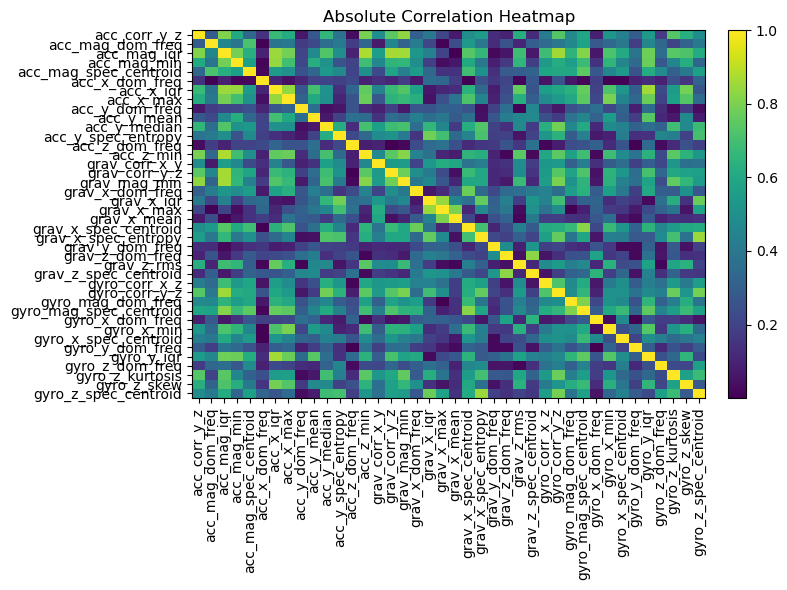

Saved correlation heatmap to corr_heatmap.png


In [16]:
#Intermediate Results
#Baseline models on filtered features (accuracy on held-out test set )
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

print("Baseline accuracies on MI-filtered features:")
for name, clf in models.items():
    clf.fit(X_train_fs, y_train)
    y_pred = clf.predict(X_test_fs)
    acc = accuracy_score(y_test, y_pred)
    print(f"  {name}: {acc:.4f}")

# Optional: visualize correlation after variance filtering
# Correlation heatmap (saved to figures/, non-blocking)
plot_correlation_heatmap(pd.DataFrame(Xf_train, columns=names_f), show=True, block=False, save_path="figures/corr_heatmap.png")
print("Saved correlation heatmap to corr_heatmap.png")

## Wrapper Methods
XXXXX

In [17]:
# Wrapper: RFE + Logistic Regression (CV summary on train only)
Xw_lr_train, names_lr, info_lr = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=LogisticRegression(max_iter=5000, solver="lbfgs", random_state=42),
    scoring="accuracy",
    cv_splits=5,
    scale_inputs=True
)
print("RFE + LR selected:", names_lr, "CV acc:", info_lr["cv_score"])

[Wrapper-RFE] Method: RFE, Kept: 15 features, CV Score: 0.9984
Selected features: ['acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'acc_z_min', 'grav_corr_y_z', 'grav_mag_min', 'grav_x_mean', 'grav_z_rms', 'grav_z_spec_centroid', 'gyro_x_spec_centroid', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
RFE + LR selected: ['acc_mag_iqr', 'acc_mag_spec_centroid', 'acc_y_dom_freq', 'acc_y_median', 'acc_y_spec_entropy', 'acc_z_min', 'grav_corr_y_z', 'grav_mag_min', 'grav_x_mean', 'grav_z_rms', 'grav_z_spec_centroid', 'gyro_x_spec_centroid', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid'] CV acc: 0.9984


In [18]:
# Wrapper: SFS (forward) + KNN (works well for distance-based models)
Xw_knn_train, names_knn, info_knn = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=KNeighborsClassifier(n_neighbors=5),
    scoring="accuracy",
    cv_splits=5,
    scale_inputs=True
)
print("SFS + KNN selected:", names_knn, "CV acc:", info_knn["cv_score"])

[Wrapper-SFS] Method: forward, Kept: 15 features, CV Score: 1.0000
Selected features: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_min', 'acc_x_iqr', 'acc_x_max', 'acc_y_median', 'acc_y_spec_entropy', 'grav_mag_min', 'grav_x_iqr', 'grav_x_mean', 'gyro_corr_x_z', 'gyro_corr_y_z', 'gyro_mag_dom_freq', 'gyro_y_iqr']
SFS + KNN selected: ['acc_corr_y_z', 'acc_mag_dom_freq', 'acc_mag_iqr', 'acc_mag_min', 'acc_x_iqr', 'acc_x_max', 'acc_y_median', 'acc_y_spec_entropy', 'grav_mag_min', 'grav_x_iqr', 'grav_x_mean', 'gyro_corr_x_z', 'gyro_corr_y_z', 'gyro_mag_dom_freq', 'gyro_y_iqr'] CV acc: 1.0


In [19]:
# Wrapper: SFS (forward) + Naive Bayes
Xw_nb_train, names_nb, info_nb = wrapper_select(
    X_train_fs, y_train,
    method="sfs_forward",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=GaussianNB(),
    scoring="accuracy",
    cv_splits=5,
    scale_inputs=True
)
print("SFS + NB selected:", names_nb, "CV acc:", info_nb["cv_score"])

[Wrapper-SFS] Method: forward, Kept: 15 features, CV Score: 0.9952
Selected features: ['acc_corr_y_z', 'acc_mag_iqr', 'acc_mag_min', 'acc_mag_spec_centroid', 'acc_y_mean', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_x_y', 'grav_mag_min', 'grav_x_max', 'grav_x_spec_entropy', 'gyro_mag_dom_freq', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid']
SFS + NB selected: ['acc_corr_y_z', 'acc_mag_iqr', 'acc_mag_min', 'acc_mag_spec_centroid', 'acc_y_mean', 'acc_y_median', 'acc_y_spec_entropy', 'grav_corr_x_y', 'grav_mag_min', 'grav_x_max', 'grav_x_spec_entropy', 'gyro_mag_dom_freq', 'gyro_y_iqr', 'gyro_z_skew', 'gyro_z_spec_centroid'] CV acc: 0.9951870967741936


In [20]:
# Wrapper: RFE + Decision Tree (trees don't need scaling)
Xw_dt_train, names_dt, info_dt = wrapper_select(
    X_train_fs, y_train,
    method="rfe",
    n_features_to_select=min(15, X_train_fs.shape[1]),
    estimator=DecisionTreeClassifier(random_state=42),
    scoring="accuracy",
    cv_splits=5,
    scale_inputs=False
)
print("RFE + DT selected:", names_dt, "CV acc:", info_dt["cv_score"])

[Wrapper-RFE] Method: RFE, Kept: 15 features, CV Score: 0.9823
Selected features: ['acc_mag_iqr', 'acc_x_dom_freq', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_mean', 'acc_y_spec_entropy', 'grav_z_rms', 'grav_z_spec_centroid', 'gyro_corr_x_z', 'gyro_corr_y_z', 'gyro_mag_dom_freq', 'gyro_mag_spec_centroid', 'gyro_y_dom_freq', 'gyro_y_iqr']
RFE + DT selected: ['acc_mag_iqr', 'acc_x_dom_freq', 'acc_x_iqr', 'acc_x_max', 'acc_y_dom_freq', 'acc_y_mean', 'acc_y_spec_entropy', 'grav_z_rms', 'grav_z_spec_centroid', 'gyro_corr_x_z', 'gyro_corr_y_z', 'gyro_mag_dom_freq', 'gyro_mag_spec_centroid', 'gyro_y_dom_freq', 'gyro_y_iqr'] CV acc: 0.9823096774193548


[VarianceThreshold] Kept: 165, Removed: 0
[CorrelationFilter] Kept: 126, Removed: 39 (|r| > 0.95)
Removed highly correlated features: ['acc_mag_max', 'acc_mag_mean', 'acc_mag_median', 'acc_mag_rms', 'acc_mag_spec_energy', 'acc_mag_std', 'acc_x_rms', 'acc_x_spec_energy', 'acc_x_std', 'acc_y_iqr', 'acc_y_max', 'acc_y_min', 'acc_y_rms', 'acc_y_spec_energy', 'acc_y_std', 'acc_z_iqr', 'acc_z_median', 'acc_z_rms', 'acc_z_spec_energy', 'acc_z_std', 'grav_mag_rms', 'grav_mag_spec_energy', 'grav_mag_std', 'grav_x_median', 'grav_x_spec_energy', 'grav_x_std', 'grav_y_rms', 'grav_y_std', 'grav_z_mean', 'grav_z_median', 'grav_z_std', 'gyro_mag_median', 'gyro_mag_rms', 'gyro_mag_std', 'gyro_x_std', 'gyro_y_rms', 'gyro_y_std', 'gyro_z_spec_energy', 'gyro_z_std']
Correlated pairs (kept -> removed, r):
  acc_mag_iqr -> acc_mag_max (r=0.956)
  acc_mag_iqr -> acc_mag_mean (r=0.975)
  acc_mag_max -> acc_mag_mean (r=0.960)
  acc_mag_iqr -> acc_mag_median (r=0.961)
  acc_mag_mean -> acc_mag_median (r=0.993)

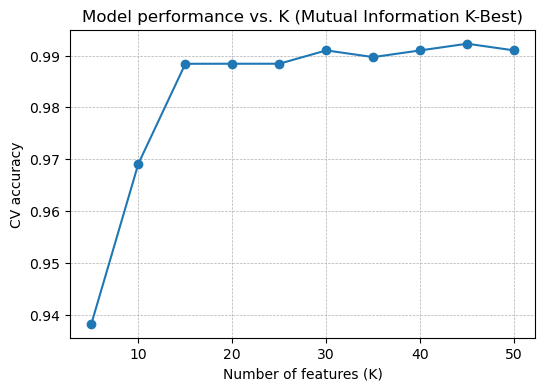

Saved MI K-curve to figures/mi_k_curve.png


In [22]:
# MI curve (optional). Saves figure; set show=True if you want to view inline.
ks, accs = accuracy_vs_k_MI(
    X, y,
    estimator=LogisticRegression(max_iter=2000, solver="lbfgs"),
    show=True, block=False, save_path="figures/mi_k_curve.png"
)
print("Saved MI K-curve to figures/mi_k_curve.png")

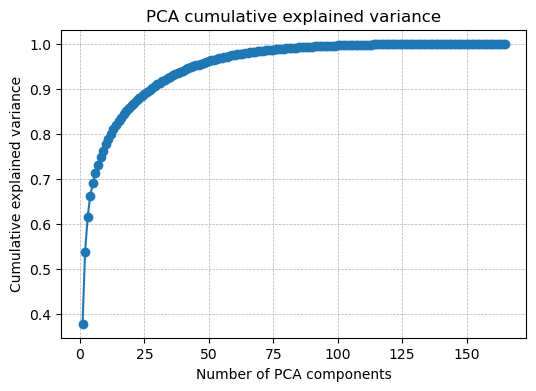

Saved PCA variance plot to figures/pca_variance.png


In [23]:
# PCA variance curve (optional). Saves figure; non-blocking.
evr, cum, pca = pca_explained_variance(
    X,
    scale_inputs=True,
    n_components=None,
    show_plot=True,
    block=False,
    save_path="figures/pca_variance.png"
)
print("Saved PCA variance plot to figures/pca_variance.png")